In [2]:
import shap

/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [1]:
import matplotlib.pyplot as plt
import shap
from catboost import Pool
#from catboost.utils import get_tree_plot
import numpy as np
from catboost_cv import PhotoZCatBoostPipeline
from catboost import CatBoostRegressor
import scienceplots
plt.style.use(['science', 'notebook', 'grid'])  # Use the science plots style

/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [ ]:
legacy['DCHISQ'][0]

NameError: name 'legacy' is not defined

In [ ]:

legacy['DCHISQ'][:,2]/(legacy['DCHISQ'][:,2]+legacy['DCHISQ'][:,3])

/tmp/ipykernel_273205/2601169479.py:1: RuntimeWarning: invalid value encountered in divide
  legacy['DCHISQ'][:,2]/(legacy['DCHISQ'][:,2]+legacy['DCHISQ'][:,3])


0.49584994
0.4978833
0.49638167
nan
0.50701755
0.49957234
0.50001097
0.47900584
0.49922413
0.5036295
0.5019245


In [ ]:
mask1 = (legacy['FLUX_G'] != 0) & (legacy['FLUX_R'] != 0) & (legacy['FLUX_Z'] != 0)

numeric_cols = [c for c in legacy.colnames if np.issubdtype(legacy[c].dtype, np.number)]

data = np.vstack([np.array(legacy[c]) for c in numeric_cols]).T

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 4093189 and the array at index 4 has size 5

In [ ]:
[np.legacy[c] for c in numeric_cols]

[<Column name='BRICKID' dtype='int32' length=4093189>
 328953
 328953
 328953
 328953
 328953
 328953
 328953
 328953
 328953
 328953
 328953
 328953
    ...
 501867
 501867
 501867
 501867
 501867
 501867
 501867
 501867
 501867
 501867
 501867,
 <Column name='OBJID' dtype='int32' length=4093189>
   88
  390
  529
  590
  726
  754
 1372
 1963
 2179
 2516
 3532
 3550
  ...
 1754
 2011
 2027
 2120
 2220
 2461
 3029
 3153
 3482
 3590
 4233,
 <Column name='RA' dtype='float64' length=4093189>
 6.2504083186842445
  6.258098548372631
  6.261985808130063
   6.26362716189572
  6.267476465634203
  6.268159870637566
 6.2846899265622875
  6.300841414862063
   6.30640575803737
  6.315761275863804
  6.342007918546039
  6.342338767180454
                ...
  351.0633580095287
 351.07805967665007
  351.0790784837181
     351.0847365743
 351.08946060529286
 351.10230275816394
  351.1342420696894
  351.1403802854679
   351.157535011184
  351.1633922174003
 351.19658679290274,
 <Column name='DEC' dtyp

In [9]:
cfg

{'data': {'region': 'south',
  'dr1': {'north': 'TABLE_DR1_north_v1_sep_1_all_features.fits',
   'south': '/user/animesh.sah/DESI_PECVEL/TABLE_DR1_south_v1_sep_1_all_features.fits'},
  'legacy': {'north': '/user/animesh.sah/DESI_PECVEL/TABLE_legacy_north_v1_sep_1_all_features.fits',
   'south': '/user/animesh.sah/DESI_PECVEL/TABLE_legacy_south_v1_sep_1_all_features.fits'}},
 'model': {'iterations': 5000,
  'depth': 7,
  'learning_rate': 0.01,
  'use_gpu': False,
  'random_state': 8513,
  'weight': None},
 'pipeline': {'mode': 'train',
  'model_path': None,
  'plot': None,
  'save_predictions': True},
 'features': ['MAG_R',
  'MAG_GR',
  'MAG_RZ',
  'MAG_W1W2',
  'MAG_ZW1',
  'SHAPE_R',
  'TYPE',
  'MODEL_WEIGHT']}

In [4]:
X.shape

(3943197, 8)

In [2]:
cfg =     PhotoZCatBoostPipeline.load_config('/user/animesh.sah/DESI_PECVEL/ML_photoz/config_catboost.yaml')
cv_pipe = PhotoZCatBoostPipeline()
DR1, legacy = cv_pipe.load_astronomical_data(cfg)
legacy = cv_pipe.compute_magnitudes(legacy)
legacy_filtered, DR1_filtered = cv_pipe.filter_data(legacy, DR1, feature_names = cfg['features'])
X, y = cv_pipe.prepare_ml_data(legacy_filtered, DR1_filtered)
cv_pipe.create_data_splits(X, y)


INFO:catboost_cv:Config loaded from /user/animesh.sah/DESI_PECVEL/ML_photoz/config_catboost.yaml
INFO:catboost_cv:Initialized PhotoZ pipeline using CPU
INFO:catboost_cv:Number of CPUs available: 32
INFO:catboost_cv:Loading astronomical data...
INFO:catboost_cv:Loading data for the region: south
INFO:catboost_cv:Data loaded in 6.59 seconds
INFO:catboost_cv:Computing magnitudes and colors...
/user/animesh.sah/DESI_PECVEL/ML_photoz/catboost_cv.py:186: RuntimeWarning: invalid value encountered in divide
  legacy['MODEL_WEIGHT'] = legacy['DCHISQ'][:,2]/(legacy['DCHISQ'][:,2]+legacy['DCHISQ'][:,3])    #(p = dchi2dev/(dchi2dev+dchi2exp))
INFO:catboost_cv:Applying data quality cuts...
INFO:catboost_cv:Using features: ['MAG_R', 'MAG_GR', 'MAG_RZ', 'MAG_W1W2', 'MAG_ZW1', 'SHAPE_R', 'MODEL_WEIGHT', 'BBA']
INFO:catboost_cv:Filtered from 4093189 to 3949575 objects


Available Columns: ['BRICKID', 'BRICKNAME', 'OBJID', 'TYPE', 'RA', 'DEC', 'DCHISQ', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2', 'FLUX_IVAR_W3', 'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2', 'MW_TRANSMISSION_W3', 'MW_TRANSMISSION_W4', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'FRACFLUX_G', 'FRACFLUX_R', 'FRACFLUX_Z', 'FRACMASKED_G', 'FRACMASKED_R', 'FRACMASKED_Z', 'FRACIN_G', 'FRACIN_R', 'FRACIN_Z', 'PSFSIZE_G', 'PSFSIZE_R', 'PSFSIZE_Z', 'PSFDEPTH_G', 'PSFDEPTH_R', 'PSFDEPTH_Z', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'FIBERFLUX_G', 'FIBERFLUX_R', 'FIBERFLUX_Z', 'GAIA_PHOT_G_MEAN_MAG', 'MASKBITS', 'SERSIC', 'Z_PHOT_MEAN', 'Z_PHOT_MEDIAN', 'Z_PHOT_L95', 'Z_SPEC', 'SURVEY', 'MAG_G', 'MAG_R', 'MAG_Z', 'MAG_W1', 'MAG_W2', 'MAG_W3', 'MAG_GR', 'MAG_RZ', 'MAG_GZ', 'MAG_W1W2', 'MAG_W2W3', 'MAG_W1W3', 'MAG_RW1', 'MAG_RW2', 'MAG_RW3', 'MAG_G

INFO:catboost_cv:Filtered from 4093189 to 3943197 objects for unique TARGETID
INFO:catboost_cv:Feature matrix shape: (3943197, 8)
INFO:catboost_cv:Target range: [0.010, 0.500]
INFO:catboost_cv:Creating data splits...
INFO:catboost_cv:Train: 2957397, Val: 492900, Test: 492900


(array([[19.283512  ,  1.1959877 ,  0.7240734 , ...,  1.6841605 ,
          0.49838904,  0.53286046],
        [18.90934   ,  1.4851627 ,  0.8094063 , ...,  4.10122   ,
          0.5053555 ,  0.5721899 ],
        [19.843098  ,  0.9473171 ,  0.6331749 , ...,  0.6457437 ,
          0.49790087,  1.        ],
        ...,
        [16.736355  ,  0.7806835 ,  0.563364  , ...,  1.8398616 ,
          0.5090825 ,  0.6551074 ],
        [17.614542  ,  0.44007874,  0.35401344, ...,  3.4006302 ,
          0.4923565 ,  0.35781518],
        [18.088936  ,  0.5021534 ,  0.39889717, ...,  2.8527446 ,
          0.49851674,  1.        ]], dtype=float32),
 array([[18.133415  ,  1.0520115 ,  0.71699905, ...,  2.259651  ,
          0.5065058 ,  0.52009547],
        [18.7431    ,  0.7722149 ,  0.5714874 , ...,  1.218121  ,
          0.49528435,  0.6782984 ],
        [19.277714  ,  1.6798325 ,  0.8610096 , ...,  0.97332376,
          0.5025365 ,  0.57682526],
        ...,
        [18.089691  ,  0.4514923 ,  0.4

In [20]:
np.isnan([np.nan,0,1,2,3,])

array([ True, False, False, False, False])

In [17]:
np.any(np.isnan(X),axis =0)

array([False, False, False, False, False, False, False, False])

In [ ]:
feature_names=['MAG_G','MAG_R','MAG_Z','MAG_W1','MAG_W2','MAG_W3','MAG_GR','MAG_RZ','MAG_GZ','MAG_W1W2','MAG_W2W3','MAG_W1W3','MAG_RW1','MAG_RW2','MAG_RW3','MAG_GW1','MAG_GW2','MAG_GW3','MAG_ZW1','MAG_ZW2','MAG_ZW3','R_CIRC','BBA','SHAPE_E1','SHAPE_E2','SERSIC','TYPE']
class CatboostInterpreter:
    def __init__(self, model, X, y=None, feature_names=None):
        self.model = model
        self.X = X
        self.y = y
        self.feature_names = feature_names
        self.pool = Pool(X, y, cat_features=[len(self.feature_names)-1] if 'TYPE' in self.feature_names else None)
        self.explainer = shap.TreeExplainer(self.model)
        self.feature_names = feature_names if feature_names!=None else [f'f{i}' for i in range(X.shape[1])]
    def plot_feature_importance(self, max_features=20):
        importance = self.model.get_feature_importance(self.pool)
        feature_importance = sorted(zip(self.feature_names, importance), key=lambda x: x[1], reverse=True)[:max_features]
        features, importances = zip(*feature_importance)
        
        plt.figure(figsize=(16, 11))
        plt.barh(features, importances)
        plt.xlabel('Importance')
        plt.title('Feature Importance')
        plt.gca().invert_yaxis()
        plt.show()
    def visualize_tree(self, tree_idx=0):
        plot = self.model.plot_tree(tree_idx=tree_idx)      
        plot.view()
    
    

In [ ]:
model = CatBoostRegressor()
model.load_model('/home/shin101/cluster_mount/Codes/catboost_model_full_features_mag_typeser_with_shapes_z_weighted_FP.cbm')

interpreter = CatboostInterpreter(model=model, X=X, y=y, feature_names=feature_names)
#interpreter = CatboostInterpreter(model='catboost_model_full_features_mag_typeser_with_shapes.cbm', X=X, y=y,feature_names=feature_names)

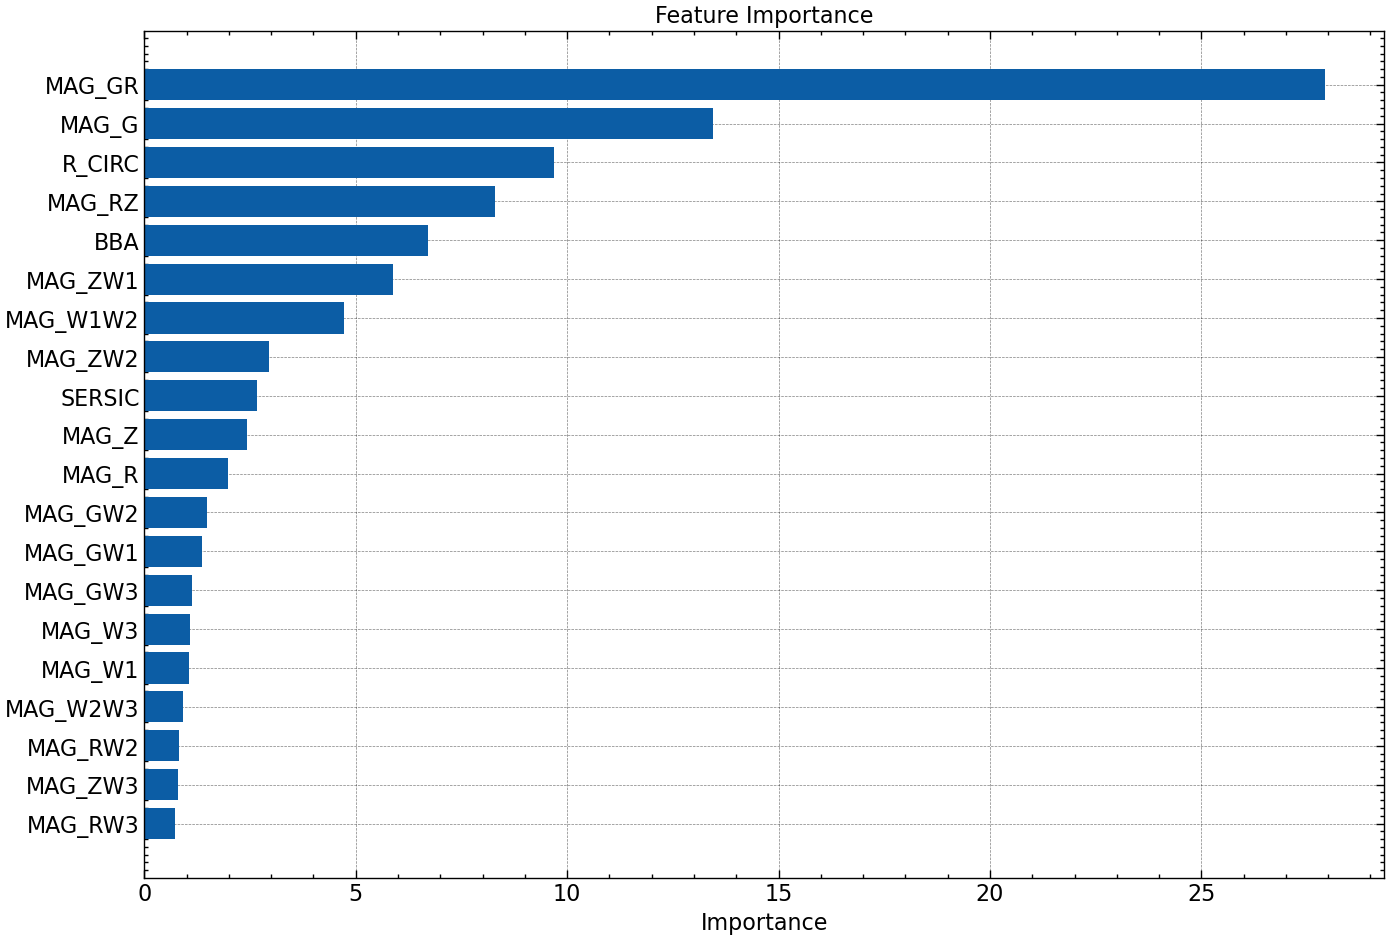

In [ ]:

interpreter.plot_feature_importance()